In [9]:
# run_HLN.py
import argparse
import os
import random
import numpy as np
import torch
from process import normalize, Protein, build_dual_graph,preprocess_HLN
from train import initialize_model, train_model
import sys
import argparse

seed = 888
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)  # cpu
torch.cuda.manual_seed_all(seed)  # gpus

In [ ]:
#Set parameters.
parser = argparse.ArgumentParser()
parser.add_argument('--device', type=str, default='cuda' if torch.cuda.is_available() else 'cpu')
parser.add_argument('--hidden_dim', type=int, default=512)
parser.add_argument('--out_dim', type=int, default=64)
parser.add_argument('--num_clusters', type=int, default=10)
parser.add_argument('--beta', type=float, default=25)
parser.add_argument('--gamma', type=float, default=10)
parser.add_argument('--delta', type=float, default=1)
parser.add_argument('--dropout', type=float, default=0)
parser.add_argument('--lr', type=float, default=1e-3)
parser.add_argument('--epochs', type=int, default=350)


_StoreAction(option_strings=['--epochs'], dest='epochs', nargs=None, const=None, default=350, type=<class 'int'>, choices=None, help=None, metavar=None)

In [ ]:

import scanpy as sc
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args, unknown = parser.parse_known_args()


adata_ADT = sc.read_h5ad('./data/HLN/adata_ADT.h5ad')
adata_RNA = sc.read_h5ad('./data/HLN/adata_RNA.h5ad')
metadata_file = os.path.join('./data/HLN/GT_labels.txt')
with open(metadata_file, 'r') as file:
    content = file.readlines()
true_labels = list(map(int, [line.strip() for line in content]))

# Preprocess RNA and ADT data (normalization, filtering, etc.)
RNA_data , ADT_data = preprocess_HLN(adata_RNA,adata_ADT)

cell_positions = adata_RNA.obsm['spatial']
graph_data = build_dual_graph(RNA_data, ADT_data, cell_positions, device=device)

# Initialize the model
model = initialize_model(graph_data, RNA_data.shape[1], ADT_data.shape[1], args)

# Train the model 
model, best_embeddings , best_labels = train_model(model, graph_data, args , true_labels)



c:\Users\23196\AppData\Local\Programs\Python\Python39\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\23196\AppData\Local\Programs\Python\Python39\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\23196\AppData\Local\Programs\Python\Python39\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\23196\AppData\Local\Programs\Python\Python39\lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\23196\AppData\Local\Programs\Python\Python39\li

Epoch 1, Total Loss: 124.4226, Recon Loss: 1.0055
Epoch 0 - ARI: 0.2155, NMI: 0.3517
Epoch 1 - ARI: 0.2157, NMI: 0.3542
Epoch 2 - ARI: 0.2188, NMI: 0.3557
Epoch 3 - ARI: 0.2191, NMI: 0.3609
Epoch 4 - ARI: 0.2284, NMI: 0.3732
Epoch 5 - ARI: 0.2335, NMI: 0.3798
Epoch 6 - ARI: 0.2318, NMI: 0.3773
Epoch 7 - ARI: 0.2612, NMI: 0.3881
Epoch 8 - ARI: 0.2437, NMI: 0.3832
Epoch 10, Total Loss: 105.8758, Recon Loss: 0.9769
Epoch 9 - ARI: 0.2265, NMI: 0.3735
Epoch 10 - ARI: 0.2456, NMI: 0.3834
Epoch 11 - ARI: 0.2325, NMI: 0.3763
Epoch 12 - ARI: 0.2363, NMI: 0.3769
Epoch 13 - ARI: 0.2388, NMI: 0.3780
Epoch 14 - ARI: 0.2729, NMI: 0.4025
Epoch 15 - ARI: 0.2429, NMI: 0.3866
Epoch 16 - ARI: 0.2760, NMI: 0.4048
Epoch 17 - ARI: 0.2402, NMI: 0.3830
Epoch 18 - ARI: 0.2708, NMI: 0.4031
Epoch 20, Total Loss: 97.7421, Recon Loss: 0.9668
Epoch 19 - ARI: 0.2682, NMI: 0.3990
Epoch 20 - ARI: 0.2381, NMI: 0.3812
Epoch 21 - ARI: 0.2709, NMI: 0.4023
Epoch 22 - ARI: 0.2702, NMI: 0.4025
Epoch 23 - ARI: 0.2683, NMI: 0.

c:\Users\23196\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


<Figure size 800x800 with 0 Axes>

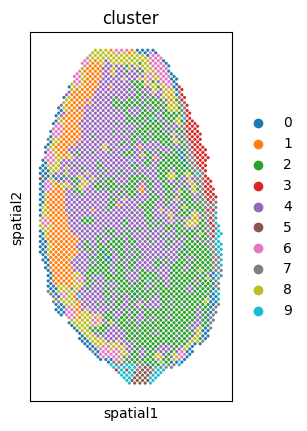

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

assert 'spatial' in adata_RNA.obsm.keys(), "Spatial coordinates not found in adata_RNA.obsm['spatial']"


adata_RNA.obs['cluster'] = pd.Categorical(best_labels)

plt.figure(figsize=(8, 8))
sc.pl.spatial(adata_RNA, color='cluster', size=1.0, spot_size=1.2,img_key=None, show=False)
plt.show()